# Fase 5 — QAOA, formulación QUBO y benchmarking clásico-cuántico

Esta fase evalúa **QAOA** como optimizador variacional sobre una subinstancia real y auditable del proyecto.

Se conserva lo validado en las fases anteriores:

- `DC00` es el **Almacén Especializado de Medicamentos de la RIS Tayacaja**, en Pampas.
- Las distancias son kilómetros **por carretera** obtenidos de OSRM/OpenStreetMap.
- La demanda sigue siendo simulada.
- La solución CVRP completa de siete destinos continúa siendo responsabilidad de la Fase 4.

El CVRP completo no se introduce directamente en un circuito: la codificación posición–destino crecería con rapidez y las restricciones de capacidad añadirían más variables. Para una prueba reproducible, QAOA optimiza el **orden de visita de una ruta real de tres IPRESS** tomada de la solución CVRP.

> Alcance: esta fase compara calidad y comportamiento algorítmico. No afirma ventaja cuántica.


## Entradas y salidas

| Tipo | Archivo | Uso |
|---|---|---|
| Entrada | `data/optimization/optimization_instance.csv` | Fuente de Tayacaja y metadatos |
| Entrada principal | `data/optimization/distance_matrix_with_source.csv` | Kilómetros viales |
| Entrada | `data/results/cvrp_solution_routes.csv` | Rutas óptimas de la Fase 4 |
| Entrada | `data/results/cvrp_solution_stops.csv` | Orden de paradas |
| Salida | `data/results/qaoa_qubo_terms.csv` | Términos lineales y cuadráticos |
| Salida | `data/results/qaoa_classical_routes.csv` | Enumeración exacta de las seis rutas |
| Salida | `data/results/qaoa_depth_results.csv` | Métricas para $p=1,2,3$ |
| Salida | `data/results/qaoa_sampled_solutions.csv` | Muestreo del mejor circuito |
| Salida | `data/results/phase5_benchmark.csv` | Comparación clásica–QAOA |
| Salidas visuales | `outputs/figures/qaoa_*.png` | Penalización, profundidad, distribución y escalabilidad |


In [1]:
from pathlib import Path
from itertools import combinations, permutations
import json
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 140)

def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "optimization").exists():
            return candidate
        nested = candidate / "qmed-colcabamba"
        if (nested / "data" / "optimization").exists():
            return nested
    raise FileNotFoundError(
        "No se encontró la raíz de qmed-colcabamba. "
        "Ejecuta el notebook dentro del repositorio."
    )

REPO_ROOT = find_repo_root()
OPT_DIR = REPO_ROOT / "data" / "optimization"
RESULTS_DIR = REPO_ROOT / "data" / "results"
FIGURES_DIR = REPO_ROOT / "outputs" / "figures"

for directory in [RESULTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

INSTANCE_PATH = OPT_DIR / "optimization_instance.csv"
DISTANCE_PATH = OPT_DIR / "distance_matrix_with_source.csv"
PHASE4_ROUTES_PATH = RESULTS_DIR / "cvrp_solution_routes.csv"
PHASE4_STOPS_PATH = RESULTS_DIR / "cvrp_solution_stops.csv"

QAOA_DEPTHS = (1, 2, 3)
QAOA_RESTARTS = 6
QAOA_MAXITER = 180
SHOTS = 4096
RANDOM_SEED = 20260723
PENALTY_MULTIPLIER = 2.5

print(f"Raíz del repositorio: {REPO_ROOT}")


Raíz del repositorio: O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte


## 1. Selección auditable de la subinstancia

Se selecciona una ruta de tres destinos producida por el solucionador exacto de la Fase 4. Esto conserva:

- una carga compatible con la capacidad simulada;
- nodos y distancias reales del caso Tayacaja–Colcabamba;
- un tamaño de circuito verificable por simulación exacta.

QAOA solo decide el orden interno de esos tres destinos. La asignación de destinos a vehículos ya fue resuelta por el CVRP.


In [2]:
instance = pd.read_csv(INSTANCE_PATH, encoding="utf-8-sig")
distance_km = pd.read_csv(
    DISTANCE_PATH, index_col=0, encoding="utf-8-sig"
)
phase4_routes = pd.read_csv(
    PHASE4_ROUTES_PATH, encoding="utf-8-sig"
)
phase4_stops = pd.read_csv(
    PHASE4_STOPS_PATH, encoding="utf-8-sig"
)

instance["NODE_ID"] = instance["NODE_ID"].astype(str)
distance_km.index = distance_km.index.astype(str)
distance_km.columns = distance_km.columns.astype(str)

source_rows = instance.loc[instance["ROLE"].eq("SOURCE")]
if len(source_rows) != 1:
    raise ValueError("Debe existir exactamente una fuente logística.")

SOURCE_ID = source_rows.iloc[0]["NODE_ID"]
SOURCE_NAME = source_rows.iloc[0]["NOMBRE"]
name_by_id = instance.set_index("NODE_ID")["NOMBRE"].to_dict()

if SOURCE_ID != "DC00" or "TAYACAJA" not in SOURCE_NAME.upper():
    raise ValueError(
        "La fuente no corresponde al almacén de la RIS Tayacaja."
    )

node_order = instance["NODE_ID"].tolist()
if (
    distance_km.index.tolist() != node_order
    or distance_km.columns.tolist() != node_order
):
    raise ValueError(
        "La matriz vial no sigue el orden de optimization_instance.csv."
    )
if distance_km.isna().any().any():
    raise ValueError("La matriz vial contiene valores faltantes.")

three_stop_routes = phase4_routes.loc[
    phase4_routes["STOPS"].eq(3)
].copy()
if three_stop_routes.empty:
    raise ValueError(
        "La Fase 4 no contiene una ruta de exactamente tres destinos."
    )

target_route = three_stop_routes.sort_values(
    ["DISTANCE_KM", "ROUTE_ID"]
).iloc[0]
SUBROUTE_ID = target_route["ROUTE_ID"]

subroute_rows = phase4_stops.loc[
    phase4_stops["ROUTE_ID"].eq(SUBROUTE_ID)
].sort_values("SEQUENCE")
sub_customers = subroute_rows.loc[
    subroute_rows["NODE_ID"].ne(SOURCE_ID), "NODE_ID"
].tolist()

if len(sub_customers) != 3 or len(set(sub_customers)) != 3:
    raise ValueError(
        "La subinstancia debe contener tres destinos distintos."
    )

sub_nodes = [SOURCE_ID, *sub_customers]
submatrix = distance_km.loc[sub_nodes, sub_nodes]
subinstance = instance.loc[
    instance["NODE_ID"].isin(sub_nodes),
    ["NODE_ID", "NOMBRE", "CATEGORIA", "ROLE", "DEMAND_UNITS"],
].copy()
subinstance["ORDEN_FASE_4"] = subinstance["NODE_ID"].map(
    {node: pos for pos, node in enumerate(sub_nodes)}
)
subinstance = subinstance.sort_values("ORDEN_FASE_4")

audit = pd.DataFrame(
    {
        "CONTROL": [
            "Fuente",
            "Matriz objetivo",
            "Ruta seleccionada",
            "Destinos QAOA",
            "Carga de la ruta",
            "Distancia de la Fase 4",
        ],
        "VALOR": [
            SOURCE_NAME,
            "OSRM por carretera (km)",
            SUBROUTE_ID,
            " → ".join(sub_customers),
            int(target_route["LOAD_UNITS"]),
            f"{target_route['DISTANCE_KM']:.4f} km",
        ],
    }
)
display(audit)
display(subinstance)
display(submatrix.round(4))


,CONTROL,VALOR
0,Fuente,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA
1,Matriz objetivo,OSRM por carretera (km)
2,Ruta seleccionada,R02
3,Destinos QAOA,IP03 → IP06 → IP05
4,Carga de la ruta,72
5,Distancia de la Fase 4,176.2848 km


,NODE_ID,NOMBRE,CATEGORIA,ROLE,DEMAND_UNITS,ORDEN_FASE_4
0,DC00,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA,CENTRO LOGÍSTICO,SOURCE,0,0
3,IP03,POCCYACC,I-1,DESTINATION,22,1
6,IP06,CHACHAS,I-1,DESTINATION,22,2
5,IP05,TOCAS,I-2,DESTINATION,28,3


,DC00,IP03,IP06,IP05
NODE_ID,,,,
DC00,0.0000,67.6916,91.6867,66.2536
IP03,67.6916,0.0000,21.4358,9.1717
IP06,91.6867,21.4358,0.0000,20.9038
IP05,66.2536,9.1717,20.9038,0.0000


## 2. Codificación binaria posición–destino

Para tres destinos y tres posiciones se definen nueve variables:

$$x_{i,t}=
\begin{cases}
1, & \text{si la IPRESS } i \text{ ocupa la posición } t,\\
0, & \text{en otro caso.}
\end{cases}$$

La distancia de una ruta es

$$C_{\mathrm{vial}}(\mathbf{x})=
\sum_i d_{0i}x_{i,0}
+\sum_{t=0}^{1}\sum_{i\neq j}d_{ij}x_{i,t}x_{j,t+1}
+\sum_i d_{i0}x_{i,2},$$

donde $0$ es el almacén de Tayacaja.

Las restricciones son:

$$\sum_t x_{i,t}=1 \quad \forall i,$$

$$\sum_i x_{i,t}=1 \quad \forall t.$$

Se incorporan mediante una penalización cuadrática:

$$C_{\mathrm{QUBO}}(\mathbf{x})=
C_{\mathrm{vial}}(\mathbf{x})
+A\sum_i\left(1-\sum_t x_{i,t}\right)^2
+A\sum_t\left(1-\sum_i x_{i,t}\right)^2.$$


In [3]:
N_DESTINATIONS = len(sub_customers)
N_POSITIONS = N_DESTINATIONS
N_QUBITS = N_DESTINATIONS * N_POSITIONS
HILBERT_SIZE = 2 ** N_QUBITS

def var_index(customer_index, position):
    return customer_index * N_POSITIONS + position

variable_records = []
for customer_index, node in enumerate(sub_customers):
    for position in range(N_POSITIONS):
        variable_records.append(
            {
                "VAR_INDEX": var_index(customer_index, position),
                "VARIABLE": f"x_{node}_{position}",
                "NODE_ID": node,
                "NOMBRE": name_by_id[node],
                "POSITION": position,
            }
        )
variables = pd.DataFrame(variable_records)

max_relevant_edge = float(submatrix.to_numpy().max())
PENALTY_A = PENALTY_MULTIPLIER * max_relevant_edge

print(f"Variables binarias / qubits: {N_QUBITS}")
print(f"Estados de la base computacional: {HILBERT_SIZE}")
print(f"Rutas válidas: {math.factorial(N_DESTINATIONS)}")
print(f"Penalización A: {PENALTY_A:.6f}")
display(variables)


Variables binarias / qubits: 9
Estados de la base computacional: 512
Rutas válidas: 6
Penalización A: 229.216750


,VAR_INDEX,VARIABLE,NODE_ID,NOMBRE,POSITION
0,0,x_IP03_0,IP03,POCCYACC,0
1,1,x_IP03_1,IP03,POCCYACC,1
2,2,x_IP03_2,IP03,POCCYACC,2
3,3,x_IP06_0,IP06,CHACHAS,0
4,4,x_IP06_1,IP06,CHACHAS,1
5,5,x_IP06_2,IP06,CHACHAS,2
6,6,x_IP05_0,IP05,TOCAS,0
7,7,x_IP05_1,IP05,TOCAS,1
8,8,x_IP05_2,IP05,TOCAS,2


### Construcción explícita del QUBO

El polinomio se guarda como

$$C_{\mathrm{QUBO}}(\mathbf{x})
=c+\sum_q h_qx_q+\sum_{q<r}J_{qr}x_qx_r.$$

La tabla de coeficientes permite reconstruir el Hamiltoniano de costo y auditar qué distancias y penalizaciones entran al circuito.


In [4]:
qubo_constant = 0.0
qubo_linear = np.zeros(N_QUBITS, dtype=float)
qubo_quadratic = np.zeros((N_QUBITS, N_QUBITS), dtype=float)

def add_linear(index, coefficient):
    qubo_linear[index] += float(coefficient)

def add_quadratic(left, right, coefficient):
    if left == right:
        add_linear(left, coefficient)
        return
    i, j = sorted((left, right))
    qubo_quadratic[i, j] += float(coefficient)

def add_exactly_one(variable_indices, penalty):
    global qubo_constant
    qubo_constant += penalty
    for index in variable_indices:
        add_linear(index, -penalty)
    for left, right in combinations(variable_indices, 2):
        add_quadratic(left, right, 2.0 * penalty)

# Salida desde Tayacaja y regreso al almacén.
for i, node in enumerate(sub_customers):
    add_linear(
        var_index(i, 0),
        distance_km.loc[SOURCE_ID, node],
    )
    add_linear(
        var_index(i, N_POSITIONS - 1),
        distance_km.loc[node, SOURCE_ID],
    )

# Desplazamientos entre posiciones consecutivas.
for position in range(N_POSITIONS - 1):
    for i, origin in enumerate(sub_customers):
        for j, destination in enumerate(sub_customers):
            if i == j:
                continue
            add_quadratic(
                var_index(i, position),
                var_index(j, position + 1),
                distance_km.loc[origin, destination],
            )

# Cada IPRESS aparece una vez.
for i in range(N_DESTINATIONS):
    add_exactly_one(
        [var_index(i, position) for position in range(N_POSITIONS)],
        PENALTY_A,
    )

# Cada posición contiene una IPRESS.
for position in range(N_POSITIONS):
    add_exactly_one(
        [var_index(i, position) for i in range(N_DESTINATIONS)],
        PENALTY_A,
    )

term_records = [
    {
        "TERM_TYPE": "CONSTANT",
        "QUBIT_I": np.nan,
        "QUBIT_J": np.nan,
        "VARIABLE_I": "1",
        "VARIABLE_J": "",
        "COEFFICIENT": qubo_constant,
    }
]
variable_name = variables.set_index("VAR_INDEX")["VARIABLE"].to_dict()
for q, coefficient in enumerate(qubo_linear):
    if not np.isclose(coefficient, 0.0):
        term_records.append(
            {
                "TERM_TYPE": "LINEAR",
                "QUBIT_I": q,
                "QUBIT_J": np.nan,
                "VARIABLE_I": variable_name[q],
                "VARIABLE_J": "",
                "COEFFICIENT": coefficient,
            }
        )
for q in range(N_QUBITS):
    for r in range(q + 1, N_QUBITS):
        coefficient = qubo_quadratic[q, r]
        if not np.isclose(coefficient, 0.0):
            term_records.append(
                {
                    "TERM_TYPE": "QUADRATIC",
                    "QUBIT_I": q,
                    "QUBIT_J": r,
                    "VARIABLE_I": variable_name[q],
                    "VARIABLE_J": variable_name[r],
                    "COEFFICIENT": coefficient,
                }
            )
qubo_terms = pd.DataFrame(term_records)
display(qubo_terms.head(18))
print(
    f"Términos: 1 constante, "
    f"{(qubo_terms['TERM_TYPE'] == 'LINEAR').sum()} lineales y "
    f"{(qubo_terms['TERM_TYPE'] == 'QUADRATIC').sum()} cuadráticos."
)


,TERM_TYPE,QUBIT_I,QUBIT_J,VARIABLE_I,VARIABLE_J,COEFFICIENT
0,CONSTANT,NaN,NaN,1,,1375.3005
1,LINEAR,0.0,NaN,x_IP03_0,,-390.7419
2,LINEAR,1.0,NaN,x_IP03_1,,-458.4335
3,LINEAR,2.0,NaN,x_IP03_2,,-390.7419
4,LINEAR,3.0,NaN,x_IP06_0,,-366.7468
5,LINEAR,4.0,NaN,x_IP06_1,,-458.4335
6,LINEAR,5.0,NaN,x_IP06_2,,-366.7468
7,LINEAR,6.0,NaN,x_IP05_0,,-392.1799
8,LINEAR,7.0,NaN,x_IP05_1,,-458.4335
9,LINEAR,8.0,NaN,x_IP05_2,,-392.1799


Términos: 1 constante, 9 lineales y 30 cuadráticos.


## 3. Validación exhaustiva del QUBO

Como $2^9=512$, se evalúan todos los estados. Esta enumeración no reemplaza QAOA: funciona como prueba unitaria del modelo y como verdad de referencia para una instancia pequeña.


In [5]:
state_indices = np.arange(HILBERT_SIZE, dtype=int)
bit_table = (
    (state_indices[:, None] >> np.arange(N_QUBITS)) & 1
).astype(float)

route_costs = np.zeros(HILBERT_SIZE, dtype=float)
constraint_violations = np.zeros(HILBERT_SIZE, dtype=float)

for i, node in enumerate(sub_customers):
    route_costs += (
        distance_km.loc[SOURCE_ID, node]
        * bit_table[:, var_index(i, 0)]
    )
    route_costs += (
        distance_km.loc[node, SOURCE_ID]
        * bit_table[:, var_index(i, N_POSITIONS - 1)]
    )

for position in range(N_POSITIONS - 1):
    for i, origin in enumerate(sub_customers):
        for j, destination in enumerate(sub_customers):
            if i == j:
                continue
            route_costs += (
                distance_km.loc[origin, destination]
                * bit_table[:, var_index(i, position)]
                * bit_table[:, var_index(j, position + 1)]
            )

for i in range(N_DESTINATIONS):
    indices = [
        var_index(i, position)
        for position in range(N_POSITIONS)
    ]
    constraint_violations += (
        1.0 - bit_table[:, indices].sum(axis=1)
    ) ** 2

for position in range(N_POSITIONS):
    indices = [
        var_index(i, position)
        for i in range(N_DESTINATIONS)
    ]
    constraint_violations += (
        1.0 - bit_table[:, indices].sum(axis=1)
    ) ** 2

qubo_energies_direct = (
    route_costs + PENALTY_A * constraint_violations
)
qubo_energies_polynomial = (
    qubo_constant + bit_table @ qubo_linear
)
for q in range(N_QUBITS):
    for r in range(q + 1, N_QUBITS):
        coefficient = qubo_quadratic[q, r]
        if not np.isclose(coefficient, 0.0):
            qubo_energies_polynomial += (
                coefficient
                * bit_table[:, q]
                * bit_table[:, r]
            )

feasible_mask = np.isclose(constraint_violations, 0.0)
assert np.allclose(
    qubo_energies_direct,
    qubo_energies_polynomial,
)
assert int(feasible_mask.sum()) == math.factorial(N_DESTINATIONS)

feasible_best_cost = float(route_costs[feasible_mask].min())
optimal_mask = feasible_mask & np.isclose(
    route_costs, feasible_best_cost
)
global_ground_mask = np.isclose(
    qubo_energies_direct,
    qubo_energies_direct.min(),
)

assert np.array_equal(global_ground_mask, optimal_mask)

validation_summary = pd.DataFrame(
    {
        "MÉTRICA": [
            "Estados evaluados",
            "Estados factibles",
            "Estados óptimos",
            "Energía mínima QUBO",
            "Distancia vial óptima",
            "Óptimo global factible",
        ],
        "VALOR": [
            HILBERT_SIZE,
            int(feasible_mask.sum()),
            int(optimal_mask.sum()),
            float(qubo_energies_direct.min()),
            feasible_best_cost,
            bool(feasible_mask[np.argmin(qubo_energies_direct)]),
        ],
    }
)
display(validation_summary)


,MÉTRICA,VALOR
0,Estados evaluados,512
1,Estados factibles,6
2,Estados óptimos,2
3,Energía mínima QUBO,176.2848
4,Distancia vial óptima,176.2848
5,Óptimo global factible,True


### Sensibilidad de la penalización

Un $A$ demasiado pequeño permite que una asignación inválida sea más barata que cualquier ruta. Se prueba una familia de multiplicadores y se conserva $A=2.5\,d_{\max}$ porque separa con margen los estados factibles e infactibles.


,PENALTY_MULTIPLIER,PENALTY_A,GROUND_ENERGY,GROUND_ROUTE_COST_KM,GROUND_VIOLATION,GROUND_IS_FEASIBLE
0,0.25,22.921675,91.6867,0.0000,4.0,False
1,0.50,45.843350,167.1120,75.4253,2.0,False
2,0.75,68.765025,176.2848,176.2848,0.0,True
3,1.00,91.686700,176.2848,176.2848,0.0,True
4,1.50,137.530050,176.2848,176.2848,0.0,True
5,2.00,183.373400,176.2848,176.2848,0.0,True
6,2.50,229.216750,176.2848,176.2848,0.0,True
7,3.00,275.060100,176.2848,176.2848,0.0,True


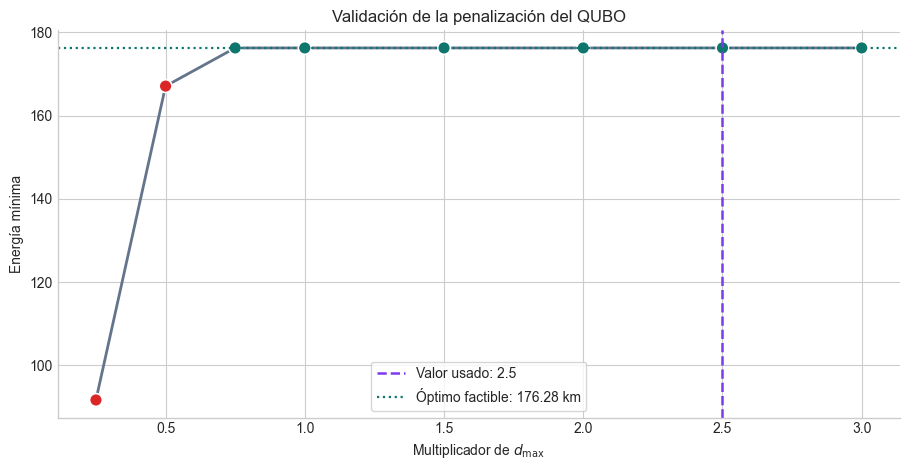

In [6]:
penalty_rows = []
for multiplier in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0]:
    penalty_value = multiplier * max_relevant_edge
    trial_energy = (
        route_costs + penalty_value * constraint_violations
    )
    best_index = int(np.argmin(trial_energy))
    penalty_rows.append(
        {
            "PENALTY_MULTIPLIER": multiplier,
            "PENALTY_A": penalty_value,
            "GROUND_ENERGY": float(trial_energy[best_index]),
            "GROUND_ROUTE_COST_KM": float(route_costs[best_index]),
            "GROUND_VIOLATION": float(
                constraint_violations[best_index]
            ),
            "GROUND_IS_FEASIBLE": bool(feasible_mask[best_index]),
        }
    )
penalty_validation = pd.DataFrame(penalty_rows)
display(penalty_validation)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
colors = penalty_validation["GROUND_IS_FEASIBLE"].map(
    {True: "#0F766E", False: "#DC2626"}
)
ax.plot(
    penalty_validation["PENALTY_MULTIPLIER"],
    penalty_validation["GROUND_ENERGY"],
    color="#64748B",
    linewidth=2,
    zorder=1,
)
ax.scatter(
    penalty_validation["PENALTY_MULTIPLIER"],
    penalty_validation["GROUND_ENERGY"],
    c=colors,
    s=85,
    edgecolor="white",
    linewidth=1.2,
    zorder=2,
)
ax.axvline(
    PENALTY_MULTIPLIER,
    color="#7C3AED",
    linestyle="--",
    linewidth=1.8,
    label=f"Valor usado: {PENALTY_MULTIPLIER}",
)
ax.axhline(
    feasible_best_cost,
    color="#0F766E",
    linestyle=":",
    linewidth=1.6,
    label=f"Óptimo factible: {feasible_best_cost:.2f} km",
)
ax.set_title("Validación de la penalización del QUBO")
ax.set_xlabel(r"Multiplicador de $d_{\max}$")
ax.set_ylabel("Energía mínima")
ax.legend(frameon=True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
penalty_figure = FIGURES_DIR / "qaoa_penalty_validation.png"
plt.savefig(penalty_figure, dpi=190, bbox_inches="tight")
plt.show()


## 4. Baseline clásico exacto

Con tres destinos existen $3!=6$ secuencias. Su costo se calcula con la misma matriz vial:

$$C(\pi)=d_{0,\pi_1}+d_{\pi_1,\pi_2}
+d_{\pi_2,\pi_3}+d_{\pi_3,0}.$$

Este óptimo clásico es la referencia para medir el *gap* de QAOA:

$$\mathrm{gap}(\%)=
\frac{C_{\mathrm{método}}-C^\star}{C^\star}\times100.$$


In [7]:
def route_distance(order):
    path = [SOURCE_ID, *order, SOURCE_ID]
    return float(
        sum(
            distance_km.loc[path[i], path[i + 1]]
            for i in range(len(path) - 1)
        )
    )

def encode_permutation(order):
    state = 0
    for position, node in enumerate(order):
        customer_index = sub_customers.index(node)
        state |= 1 << var_index(customer_index, position)
    return state

def decode_feasible_state(state_index):
    if not feasible_mask[state_index]:
        return None
    bits = bit_table[state_index]
    order = []
    for position in range(N_POSITIONS):
        chosen = [
            sub_customers[i]
            for i in range(N_DESTINATIONS)
            if bits[var_index(i, position)] == 1
        ]
        if len(chosen) != 1:
            return None
        order.append(chosen[0])
    return tuple(order)

classical_start = time.perf_counter()
classical_rows = []
for order in permutations(sub_customers):
    state_index = encode_permutation(order)
    cost = route_distance(order)
    classical_rows.append(
        {
            "STATE_INDEX": state_index,
            "ORDER_NODE_IDS": " -> ".join(order),
            "ROUTE_NODE_IDS": (
                f"{SOURCE_ID} -> "
                + " -> ".join(order)
                + f" -> {SOURCE_ID}"
            ),
            "ROUTE_NAMES": (
                f"{name_by_id[SOURCE_ID]} -> "
                + " -> ".join(name_by_id[node] for node in order)
                + f" -> {name_by_id[SOURCE_ID]}"
            ),
            "ROAD_DISTANCE_KM": cost,
        }
    )
exact_runtime_s = time.perf_counter() - classical_start

classical_routes = pd.DataFrame(classical_rows).sort_values(
    ["ROAD_DISTANCE_KM", "ORDER_NODE_IDS"]
).reset_index(drop=True)
CLASSICAL_OPTIMUM_KM = float(
    classical_routes["ROAD_DISTANCE_KM"].min()
)
classical_routes["IS_OPTIMAL"] = np.isclose(
    classical_routes["ROAD_DISTANCE_KM"],
    CLASSICAL_OPTIMUM_KM,
)
classical_routes["GAP_TO_OPTIMUM_PCT"] = (
    100.0
    * (
        classical_routes["ROAD_DISTANCE_KM"]
        - CLASSICAL_OPTIMUM_KM
    )
    / CLASSICAL_OPTIMUM_KM
)

nearest_start = time.perf_counter()
remaining = set(sub_customers)
nearest_order = []
current = SOURCE_ID
while remaining:
    next_node = min(
        remaining,
        key=lambda node: (
            distance_km.loc[current, node],
            node,
        ),
    )
    nearest_order.append(next_node)
    remaining.remove(next_node)
    current = next_node
nearest_runtime_s = time.perf_counter() - nearest_start
nearest_cost_km = route_distance(nearest_order)

phase4_order = tuple(sub_customers)
phase4_cost_km = route_distance(phase4_order)

assert np.isclose(CLASSICAL_OPTIMUM_KM, feasible_best_cost)
assert np.isclose(
    phase4_cost_km,
    float(target_route["DISTANCE_KM"]),
)

display(classical_routes)
print(
    "Vecino más cercano: "
    f"{' -> '.join(nearest_order)} = {nearest_cost_km:.4f} km"
)


,STATE_INDEX,ORDER_NODE_IDS,ROUTE_NODE_IDS,ROUTE_NAMES,ROAD_DISTANCE_KM,IS_OPTIMAL,GAP_TO_OPTIMUM_PCT
0,273,IP03 -> IP06 -> IP05,DC00 -> IP03 -> IP06 -> IP05 -> DC00,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA -> POCCYACC -> CHACHAS -> TOCAS -> ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA ...,176.2848,True,0.000000
1,84,IP05 -> IP06 -> IP03,DC00 -> IP05 -> IP06 -> IP03 -> DC00,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA -> TOCAS -> CHACHAS -> POCCYACC -> ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA ...,176.2848,True,0.000000
2,98,IP05 -> IP03 -> IP06,DC00 -> IP05 -> IP03 -> IP06 -> DC00,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA -> TOCAS -> POCCYACC -> CHACHAS -> ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA ...,188.5478,False,6.956357
3,266,IP06 -> IP03 -> IP05,DC00 -> IP06 -> IP03 -> IP05 -> DC00,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA -> CHACHAS -> POCCYACC -> TOCAS -> ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA ...,188.5478,False,6.956357
4,161,IP03 -> IP05 -> IP06,DC00 -> IP03 -> IP05 -> IP06 -> DC00,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA -> POCCYACC -> TOCAS -> CHACHAS -> ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA ...,189.4538,False,7.470298
5,140,IP06 -> IP05 -> IP03,DC00 -> IP06 -> IP05 -> IP03 -> DC00,ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA RIS TAYACAJA -> CHACHAS -> TOCAS -> POCCYACC -> ALMACÉN ESPECIALIZADO DE MEDICAMENTOS DE LA ...,189.4538,False,7.470298


Vecino más cercano: IP05 -> IP03 -> IP06 = 188.5478 km


## 5. QAOA por simulación exacta de estado

QAOA prepara

$$|\psi(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle
=\prod_{\ell=1}^{p}
e^{-i\beta_\ell H_M}
e^{-i\gamma_\ell H_C}
|+\rangle^{\otimes 9},$$

con:

- $H_C$: Hamiltoniano diagonal derivado del QUBO;
- $H_M=\sum_q X_q$: mezclador estándar;
- $p$: profundidad QAOA;
- un optimizador clásico COBYLA para ajustar ángulos.

La energía se normaliza solo para mejorar la estabilidad numérica de los ángulos. Este reescalamiento no cambia el estado fundamental.


In [8]:
energy_min = float(qubo_energies_direct.min())
energy_range = float(
    qubo_energies_direct.max() - qubo_energies_direct.min()
)
normalized_energies = (
    qubo_energies_direct - energy_min
) / energy_range

def qaoa_statevector(parameters, depth):
    parameters = np.asarray(parameters, dtype=float)
    if parameters.size != 2 * depth:
        raise ValueError(
            f"Se esperaban {2 * depth} parámetros."
        )

    gammas = parameters[:depth]
    betas = parameters[depth:]
    state = np.ones(HILBERT_SIZE, dtype=complex)
    state /= np.sqrt(HILBERT_SIZE)

    for gamma, beta in zip(gammas, betas):
        # U_C(gamma): fase dependiente de la energía QUBO.
        state *= np.exp(
            -1j * gamma * normalized_energies
        )

        # U_M(beta): producto de rotaciones exp(-i beta X_q).
        cosine = np.cos(beta)
        sine = -1j * np.sin(beta)
        for qubit in range(N_QUBITS):
            block = 1 << qubit
            view = state.reshape(-1, 2 * block)
            left = view[:, :block].copy()
            right = view[:, block:].copy()
            view[:, :block] = cosine * left + sine * right
            view[:, block:] = sine * left + cosine * right

    return state

def qaoa_expectation(parameters, depth):
    probabilities = np.abs(
        qaoa_statevector(parameters, depth)
    ) ** 2
    return float(
        np.dot(probabilities, normalized_energies)
    )

# Pruebas unitarias de norma y dominio.
test_parameters = np.zeros(2)
test_state = qaoa_statevector(test_parameters, depth=1)
assert np.isclose(np.vdot(test_state, test_state).real, 1.0)
assert np.isclose(
    qaoa_expectation(test_parameters, depth=1),
    normalized_energies.mean(),
)
print("Simulador QAOA validado.")


Simulador QAOA validado.


### Optimización de parámetros

Para reducir la dependencia de una inicialización afortunada se ejecutan varias semillas por profundidad. La selección usa la menor esperanza de energía, no información sobre el índice del óptimo.


In [9]:
qaoa_rows = []
restart_rows = []
best_results = {}
best_states = {}

for depth in QAOA_DEPTHS:
    depth_start = time.perf_counter()
    best_result = None

    for restart in range(QAOA_RESTARTS):
        rng = np.random.default_rng(
            RANDOM_SEED + 1000 * depth + restart
        )
        initial_parameters = np.concatenate(
            [
                rng.uniform(0.0, 2.0 * np.pi, depth),
                rng.uniform(0.0, np.pi, depth),
            ]
        )
        run_start = time.perf_counter()
        result = minimize(
            qaoa_expectation,
            initial_parameters,
            args=(depth,),
            method="COBYLA",
            options={
                "maxiter": QAOA_MAXITER,
                "rhobeg": 0.7,
                "tol": 1e-7,
            },
        )
        run_time_s = time.perf_counter() - run_start
        restart_rows.append(
            {
                "DEPTH_P": depth,
                "RESTART": restart,
                "SEED": RANDOM_SEED + 1000 * depth + restart,
                "SUCCESS": bool(result.success),
                "NFEV": int(result.nfev),
                "NORMALIZED_EXPECTATION": float(result.fun),
                "RUNTIME_S": run_time_s,
            }
        )
        if (
            best_result is None
            or result.fun < best_result.fun
        ):
            best_result = result

    depth_runtime_s = time.perf_counter() - depth_start
    state = qaoa_statevector(best_result.x, depth)
    probabilities = np.abs(state) ** 2
    modal_index = int(np.argmax(probabilities))
    feasible_indices = np.flatnonzero(feasible_mask)
    modal_feasible_index = int(
        feasible_indices[
            np.argmax(probabilities[feasible_indices])
        ]
    )

    feasibility_probability = float(
        probabilities[feasible_mask].sum()
    )
    optimum_probability = float(
        probabilities[optimal_mask].sum()
    )
    conditional_optimum_probability = (
        optimum_probability / feasibility_probability
        if feasibility_probability > 0
        else 0.0
    )

    qaoa_rows.append(
        {
            "DEPTH_P": depth,
            "QUBITS": N_QUBITS,
            "RESTARTS": QAOA_RESTARTS,
            "BEST_NFEV": int(best_result.nfev),
            "TOTAL_RUNTIME_S": depth_runtime_s,
            "NORMALIZED_EXPECTATION": float(best_result.fun),
            "EXPECTED_QUBO_ENERGY": float(
                np.dot(probabilities, qubo_energies_direct)
            ),
            "FEASIBILITY_PROBABILITY": feasibility_probability,
            "OPTIMUM_PROBABILITY": optimum_probability,
            "OPTIMUM_PROBABILITY_CONDITIONAL": (
                conditional_optimum_probability
            ),
            "MODAL_STATE_INDEX": modal_index,
            "MODAL_STATE_PROBABILITY": float(
                probabilities[modal_index]
            ),
            "MODAL_STATE_IS_FEASIBLE": bool(
                feasible_mask[modal_index]
            ),
            "BEST_FEASIBLE_STATE_INDEX": modal_feasible_index,
            "BEST_FEASIBLE_STATE_PROBABILITY": float(
                probabilities[modal_feasible_index]
            ),
            "BEST_FEASIBLE_ROUTE_KM": float(
                route_costs[modal_feasible_index]
            ),
            "BEST_PARAMETERS": json.dumps(
                best_result.x.tolist()
            ),
        }
    )
    best_results[depth] = best_result
    best_states[depth] = state

qaoa_depth_results = pd.DataFrame(qaoa_rows)
qaoa_restarts = pd.DataFrame(restart_rows)
display(
    qaoa_depth_results[
        [
            "DEPTH_P",
            "TOTAL_RUNTIME_S",
            "NORMALIZED_EXPECTATION",
            "FEASIBILITY_PROBABILITY",
            "OPTIMUM_PROBABILITY",
            "OPTIMUM_PROBABILITY_CONDITIONAL",
            "BEST_FEASIBLE_ROUTE_KM",
        ]
    ]
)


,DEPTH_P,TOTAL_RUNTIME_S,NORMALIZED_EXPECTATION,FEASIBILITY_PROBABILITY,OPTIMUM_PROBABILITY,OPTIMUM_PROBABILITY_CONDITIONAL,BEST_FEASIBLE_ROUTE_KM
0,1,1.866066,0.093721,0.096667,0.032384,0.335009,176.2848
1,2,1.722796,0.083354,0.136631,0.045823,0.335378,176.2848
2,3,1.782166,0.082100,0.148367,0.049751,0.335324,176.2848


## 6. Muestreo y decodificación

El mejor $p$ se elige por energía esperada. Luego se simulan 4096 mediciones. Se reportan por separado:

- probabilidad total de factibilidad;
- probabilidad total de una ruta óptima;
- ruta factible más probable;
- frecuencia empírica con un número finito de *shots*.

Esta separación evita confundir una energía promedio baja con una garantía de obtener siempre la ruta óptima.


In [10]:
BEST_DEPTH = int(
    qaoa_depth_results.sort_values(
        ["NORMALIZED_EXPECTATION", "DEPTH_P"]
    ).iloc[0]["DEPTH_P"]
)
best_state = best_states[BEST_DEPTH]
best_probabilities = np.abs(best_state) ** 2

rng = np.random.default_rng(RANDOM_SEED + 99)
samples = rng.choice(
    HILBERT_SIZE,
    size=SHOTS,
    p=best_probabilities,
)
unique_states, sample_counts = np.unique(
    samples, return_counts=True
)

sampled_rows = []
for state_index, count in zip(unique_states, sample_counts):
    decoded = decode_feasible_state(int(state_index))
    is_feasible = decoded is not None
    sampled_rows.append(
        {
            "STATE_INDEX": int(state_index),
            "BITSTRING_Q0_TO_Q8": "".join(
                str(int(bit))
                for bit in bit_table[state_index]
            ),
            "COUNT": int(count),
            "EMPIRICAL_PROBABILITY": count / SHOTS,
            "THEORETICAL_PROBABILITY": float(
                best_probabilities[state_index]
            ),
            "IS_FEASIBLE": is_feasible,
            "IS_OPTIMAL": bool(optimal_mask[state_index]),
            "ORDER_NODE_IDS": (
                " -> ".join(decoded)
                if is_feasible
                else "INFACTIBLE"
            ),
            "ROAD_DISTANCE_KM": (
                route_distance(decoded)
                if is_feasible
                else np.nan
            ),
            "CONSTRAINT_VIOLATION": float(
                constraint_violations[state_index]
            ),
            "QUBO_ENERGY": float(
                qubo_energies_direct[state_index]
            ),
        }
    )

qaoa_sampled = pd.DataFrame(sampled_rows).sort_values(
    ["COUNT", "STATE_INDEX"],
    ascending=[False, True],
).reset_index(drop=True)

feasible_indices = np.flatnonzero(feasible_mask)
qaoa_selected_state = int(
    feasible_indices[
        np.argmax(best_probabilities[feasible_indices])
    ]
)
qaoa_selected_order = decode_feasible_state(
    qaoa_selected_state
)
qaoa_selected_cost_km = route_distance(qaoa_selected_order)
qaoa_selected_gap_pct = (
    100.0
    * (qaoa_selected_cost_km - CLASSICAL_OPTIMUM_KM)
    / CLASSICAL_OPTIMUM_KM
)

theoretical_optimum_probability = float(
    best_probabilities[optimal_mask].sum()
)
empirical_optimum_probability = float(
    np.mean(optimal_mask[samples])
)
uniform_optimum_probability = (
    float(optimal_mask.sum()) / HILBERT_SIZE
)
amplification_vs_uniform = (
    theoretical_optimum_probability
    / uniform_optimum_probability
)

sample_summary = pd.DataFrame(
    {
        "MÉTRICA": [
            "Profundidad elegida",
            "Shots",
            "Probabilidad teórica del óptimo",
            "Frecuencia empírica del óptimo",
            "Probabilidad uniforme del óptimo",
            "Factor respecto de uniforme",
            "Ruta factible más probable",
            "Distancia seleccionada",
            "Gap de la ruta seleccionada",
        ],
        "VALOR": [
            BEST_DEPTH,
            SHOTS,
            theoretical_optimum_probability,
            empirical_optimum_probability,
            uniform_optimum_probability,
            amplification_vs_uniform,
            " -> ".join(qaoa_selected_order),
            qaoa_selected_cost_km,
            qaoa_selected_gap_pct,
        ],
    }
)
display(sample_summary)
display(qaoa_sampled.head(15))


,MÉTRICA,VALOR
0,Profundidad elegida,3
1,Shots,4096
2,Probabilidad teórica del óptimo,0.049751
3,Frecuencia empírica del óptimo,0.044189
4,Probabilidad uniforme del óptimo,0.003906
5,Factor respecto de uniforme,12.736223
6,Ruta factible más probable,IP05 -> IP06 -> IP03
7,Distancia seleccionada,176.2848
8,Gap de la ruta seleccionada,0.0


,STATE_INDEX,BITSTRING_Q0_TO_Q8,COUNT,EMPIRICAL_PROBABILITY,THEORETICAL_PROBABILITY,IS_FEASIBLE,IS_OPTIMAL,ORDER_NODE_IDS,ROAD_DISTANCE_KM,CONSTRAINT_VIOLATION,QUBO_ENERGY
0,161,100001010,108,0.026367,0.024644,True,False,IP03 -> IP05 -> IP06,189.4538,0.0,189.4538
1,266,010100001,104,0.025391,0.024664,True,False,IP06 -> IP03 -> IP05,188.5478,0.0,188.5478
2,98,010001100,100,0.024414,0.024664,True,False,IP05 -> IP03 -> IP06,188.5478,0.0,188.5478
3,140,001100010,96,0.023438,0.024644,True,False,IP06 -> IP05 -> IP03,189.4538,0.0,189.4538
4,273,100010001,94,0.022949,0.024875,True,True,IP03 -> IP06 -> IP05,176.2848,0.0,176.2848
5,84,001010100,87,0.021240,0.024875,True,True,IP05 -> IP06 -> IP03,176.2848,0.0,176.2848
6,129,100000010,87,0.021240,0.016233,False,False,INFACTIBLE,NaN,2.0,535.2968
7,80,000010100,76,0.018555,0.015370,False,False,INFACTIBLE,NaN,2.0,545.5909
8,10,010100000,69,0.016846,0.014783,False,False,INFACTIBLE,NaN,2.0,571.5560
9,258,010000001,69,0.016846,0.016264,False,False,INFACTIBLE,NaN,2.0,533.8588


## 7. Verificación opcional con Qiskit

La simulación NumPy anterior implementa exactamente las capas QAOA y no requiere Qiskit. Si Qiskit está instalado, esta celda reconstruye el circuito con compuertas `RZ`, `RZZ` y `RX`, y compara su distribución con el estado anterior.

La correspondencia usada es $x_q=(1-Z_q)/2$.


In [11]:
qiskit_available = False
qiskit_probability_difference = np.nan
qiskit_depth = np.nan
qiskit_size = np.nan

try:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector

    qiskit_available = True
    best_parameters = best_results[BEST_DEPTH].x
    gammas = best_parameters[:BEST_DEPTH]
    betas = best_parameters[BEST_DEPTH:]

    qc = QuantumCircuit(N_QUBITS)
    qc.h(range(N_QUBITS))

    for gamma, beta in zip(gammas, betas):
        for q, coefficient in enumerate(qubo_linear):
            normalized_coefficient = coefficient / energy_range
            if not np.isclose(normalized_coefficient, 0.0):
                qc.rz(
                    -gamma * normalized_coefficient,
                    q,
                )

        for q in range(N_QUBITS):
            for r in range(q + 1, N_QUBITS):
                coefficient = qubo_quadratic[q, r]
                normalized_coefficient = (
                    coefficient / energy_range
                )
                if np.isclose(normalized_coefficient, 0.0):
                    continue
                qc.rz(
                    -gamma * normalized_coefficient / 2.0,
                    q,
                )
                qc.rz(
                    -gamma * normalized_coefficient / 2.0,
                    r,
                )
                qc.rzz(
                    gamma * normalized_coefficient / 2.0,
                    q,
                    r,
                )

        for q in range(N_QUBITS):
            qc.rx(2.0 * beta, q)

    qiskit_state = Statevector.from_instruction(qc)
    qiskit_probabilities = np.abs(
        np.asarray(qiskit_state.data)
    ) ** 2
    qiskit_probability_difference = float(
        np.max(
            np.abs(
                qiskit_probabilities - best_probabilities
            )
        )
    )
    qiskit_depth = int(qc.depth())
    qiskit_size = int(qc.size())

    print(qc.draw(output="text", fold=120))
    print(
        "Máxima diferencia de probabilidad "
        f"Qiskit–NumPy: {qiskit_probability_difference:.3e}"
    )
    if qiskit_probability_difference > 1e-8:
        print(
            "Advertencia: revisa la convención de bits de la "
            "versión de Qiskit instalada."
        )
except ImportError:
    print(
        "Qiskit no está instalado. La implementación NumPy ya "
        "ejecutó QAOA por estado exacto. En Colab puedes instalar "
        "qiskit para visualizar y verificar el circuito."
    )


     ┌───┐┌─────────────┐ ┌──────────────┐               ┌──────────────┐              ┌──────────────┐              »
q_0: ┤ H ├┤ Rz(0.39909) ├─┤ Rz(-0.23411) ├──■────────────┤ Rz(-0.23411) ├─■────────────┤ Rz(-0.23411) ├─■────────────»
     ├───┤├─────────────┤ ├──────────────┤  │ZZ(0.23411) ├──────────────┤ │            └──────────────┘ │            »
q_1: ┤ H ├┤ Rz(0.46822) ├─┤ Rz(-0.23411) ├──■────────────┤ Rz(-0.23411) ├─┼─────────────────────────────┼────────────»
     ├───┤├─────────────┤ ├──────────────┤               └──────────────┘ │ZZ(0.23411) ┌──────────────┐ │            »
q_2: ┤ H ├┤ Rz(0.39909) ├─┤ Rz(-0.23411) ├────────────────────────────────■────────────┤ Rz(-0.23411) ├─┼────────────»
     ├───┤├─────────────┤ ├──────────────┤                                             └──────────────┘ │ZZ(0.23411) »
q_3: ┤ H ├┤ Rz(0.37458) ├─┤ Rz(-0.23411) ├──────────────────────────────────────────────────────────────■────────────»
     ├───┤├─────────────┤┌┴──────────────┤      

## 8. Benchmark clásico–cuántico

Los métodos se comparan en el mismo subproblema de ordenamiento. El tiempo de QAOA incluye múltiples reinicios y simulación exacta; no es comparable con tiempo de hardware cuántico. Se reporta para reproducibilidad, no como evidencia de aceleración.


In [12]:
best_depth_row = qaoa_depth_results.loc[
    qaoa_depth_results["DEPTH_P"].eq(BEST_DEPTH)
].iloc[0]

benchmark = pd.DataFrame(
    [
        {
            "METHOD": "Vecino más cercano",
            "TYPE": "Clásico heurístico",
            "SELECTED_ROUTE": " -> ".join(nearest_order),
            "ROAD_DISTANCE_KM": nearest_cost_km,
            "GAP_TO_OPTIMUM_PCT": (
                100.0
                * (nearest_cost_km - CLASSICAL_OPTIMUM_KM)
                / CLASSICAL_OPTIMUM_KM
            ),
            "FEASIBLE": True,
            "OPTIMUM_PROBABILITY": np.nan,
            "RUNTIME_S": nearest_runtime_s,
        },
        {
            "METHOD": "Enumeración exacta",
            "TYPE": "Clásico exacto",
            "SELECTED_ROUTE": classical_routes.iloc[0][
                "ORDER_NODE_IDS"
            ],
            "ROAD_DISTANCE_KM": CLASSICAL_OPTIMUM_KM,
            "GAP_TO_OPTIMUM_PCT": 0.0,
            "FEASIBLE": True,
            "OPTIMUM_PROBABILITY": 1.0,
            "RUNTIME_S": exact_runtime_s,
        },
        {
            "METHOD": f"QAOA p={BEST_DEPTH}",
            "TYPE": "Híbrido cuántico-clásico",
            "SELECTED_ROUTE": " -> ".join(
                qaoa_selected_order
            ),
            "ROAD_DISTANCE_KM": qaoa_selected_cost_km,
            "GAP_TO_OPTIMUM_PCT": qaoa_selected_gap_pct,
            "FEASIBLE": True,
            "OPTIMUM_PROBABILITY": (
                theoretical_optimum_probability
            ),
            "RUNTIME_S": float(
                best_depth_row["TOTAL_RUNTIME_S"]
            ),
        },
    ]
)
display(benchmark)


,METHOD,TYPE,SELECTED_ROUTE,ROAD_DISTANCE_KM,GAP_TO_OPTIMUM_PCT,FEASIBLE,OPTIMUM_PROBABILITY,RUNTIME_S
0,Vecino más cercano,Clásico heurístico,IP05 -> IP03 -> IP06,188.5478,6.956357,True,NaN,0.000432
1,Enumeración exacta,Clásico exacto,IP03 -> IP06 -> IP05,176.2848,0.000000,True,1.000000,0.000599
2,QAOA p=3,Híbrido cuántico-clásico,IP05 -> IP06 -> IP03,176.2848,0.000000,True,0.049751,1.782166


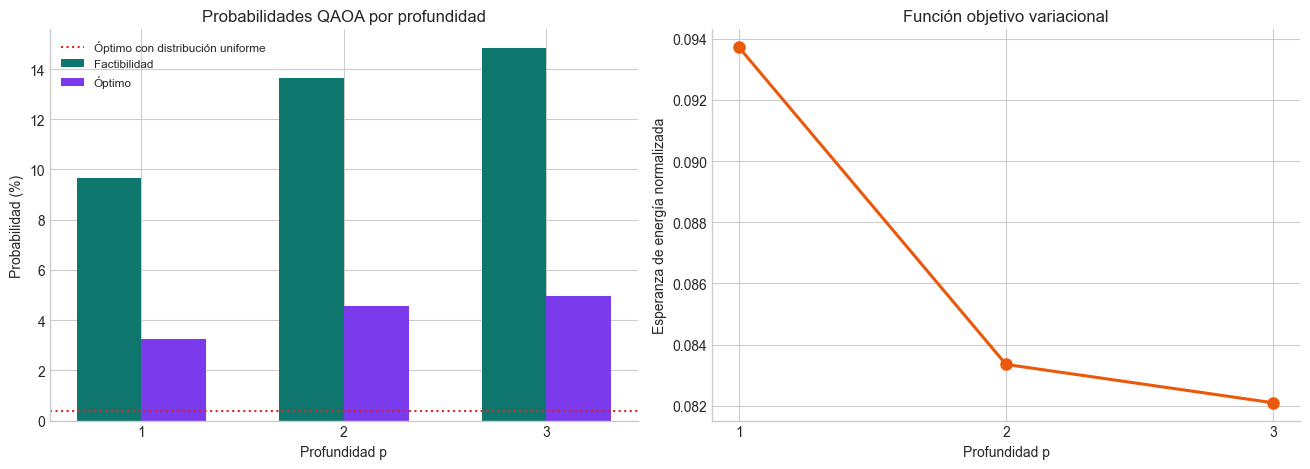

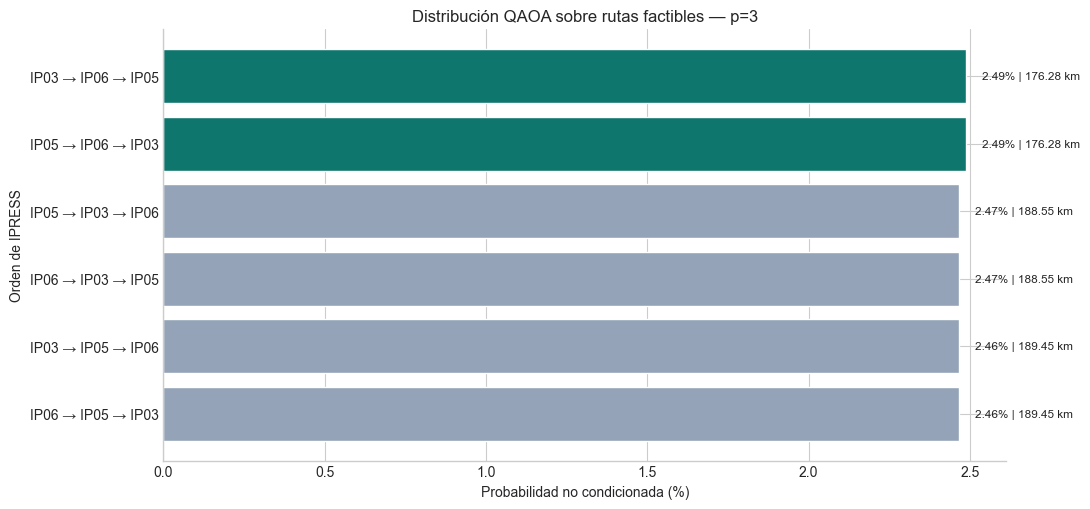

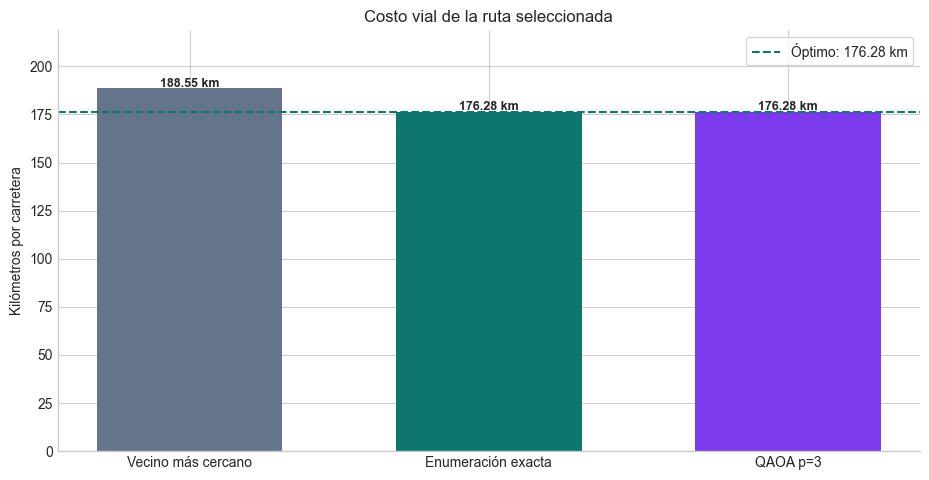

In [13]:
# Figura 1: desempeño con la profundidad.
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

depths = qaoa_depth_results["DEPTH_P"].to_numpy()
feasibility_pct = (
    100.0
    * qaoa_depth_results["FEASIBILITY_PROBABILITY"].to_numpy()
)
optimum_pct = (
    100.0
    * qaoa_depth_results["OPTIMUM_PROBABILITY"].to_numpy()
)
width = 0.32
axes[0].bar(
    depths - width / 2,
    feasibility_pct,
    width=width,
    color="#0F766E",
    label="Factibilidad",
)
axes[0].bar(
    depths + width / 2,
    optimum_pct,
    width=width,
    color="#7C3AED",
    label="Óptimo",
)
axes[0].axhline(
    100.0 * uniform_optimum_probability,
    color="#DC2626",
    linestyle=":",
    label="Óptimo con distribución uniforme",
)
axes[0].set_title("Probabilidades QAOA por profundidad")
axes[0].set_xlabel("Profundidad p")
axes[0].set_ylabel("Probabilidad (%)")
axes[0].set_xticks(depths)
axes[0].legend(fontsize=8.5)

axes[1].plot(
    depths,
    qaoa_depth_results["NORMALIZED_EXPECTATION"],
    marker="o",
    markersize=8,
    linewidth=2.2,
    color="#EA580C",
)
axes[1].set_title("Función objetivo variacional")
axes[1].set_xlabel("Profundidad p")
axes[1].set_ylabel("Esperanza de energía normalizada")
axes[1].set_xticks(depths)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
depth_figure = FIGURES_DIR / "qaoa_depth_benchmark.png"
plt.savefig(depth_figure, dpi=190, bbox_inches="tight")
plt.show()

# Figura 2: probabilidad QAOA sobre las seis rutas válidas.
route_distribution = classical_routes.copy()
route_distribution["QAOA_PROBABILITY"] = (
    route_distribution["STATE_INDEX"].map(
        lambda state: best_probabilities[int(state)]
    )
)
route_distribution["LABEL"] = route_distribution[
    "ORDER_NODE_IDS"
].str.replace(" -> ", " → ", regex=False)

fig, ax = plt.subplots(figsize=(11.0, 5.2))
bar_colors = route_distribution["IS_OPTIMAL"].map(
    {True: "#0F766E", False: "#94A3B8"}
)
bars = ax.barh(
    route_distribution["LABEL"],
    100.0 * route_distribution["QAOA_PROBABILITY"],
    color=bar_colors,
    edgecolor="white",
)
for bar, (_, row) in zip(
    bars, route_distribution.iterrows()
):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{100 * row['QAOA_PROBABILITY']:.2f}% | "
        f"{row['ROAD_DISTANCE_KM']:.2f} km",
        va="center",
        fontsize=8.5,
    )
ax.set_title(
    f"Distribución QAOA sobre rutas factibles — p={BEST_DEPTH}"
)
ax.set_xlabel("Probabilidad no condicionada (%)")
ax.set_ylabel("Orden de IPRESS")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
distribution_figure = (
    FIGURES_DIR / "qaoa_route_distribution.png"
)
plt.savefig(
    distribution_figure, dpi=190, bbox_inches="tight"
)
plt.show()

# Figura 3: costo de la solución entregada por cada método.
fig, ax = plt.subplots(figsize=(9.4, 4.9))
method_colors = ["#64748B", "#0F766E", "#7C3AED"]
bars = ax.bar(
    benchmark["METHOD"],
    benchmark["ROAD_DISTANCE_KM"],
    color=method_colors,
    width=0.62,
)
ax.axhline(
    CLASSICAL_OPTIMUM_KM,
    color="#0F766E",
    linestyle="--",
    linewidth=1.5,
    label=f"Óptimo: {CLASSICAL_OPTIMUM_KM:.2f} km",
)
for bar, value in zip(bars, benchmark["ROAD_DISTANCE_KM"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.8,
        f"{value:.2f} km",
        ha="center",
        fontweight="bold",
        fontsize=9,
    )
ax.set_ylim(
    0,
    benchmark["ROAD_DISTANCE_KM"].max() * 1.16,
)
ax.set_title("Costo vial de la ruta seleccionada")
ax.set_ylabel("Kilómetros por carretera")
ax.legend(frameon=True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
comparison_figure = (
    FIGURES_DIR / "qaoa_method_comparison.png"
)
plt.savefig(
    comparison_figure, dpi=190, bbox_inches="tight"
)
plt.show()


## 9. Escalabilidad

Con la codificación posición–destino, una ruta de $n$ destinos usa $n^2$ qubits y el simulador de estado completo maneja $2^{n^2}$ amplitudes. Solo $n!$ estados representan permutaciones válidas.

Este crecimiento explica por qué se usa una subinstancia de tres destinos y por qué los resultados no deben extrapolarse como si el CVRP completo cupiera en el mismo circuito.


,DESTINATIONS,POSITION_VARIABLES_QUBITS,VALID_ROUTES,LOG10_HILBERT_STATES,LOG10_FEASIBLE_FRACTION
0,2,4,2,1.20412,-0.903090
1,3,9,6,2.70927,-1.931119
2,4,16,24,4.81648,-3.436269
3,5,25,120,7.52575,-5.446569
4,6,36,720,10.83708,-7.979747
5,7,49,5040,14.75047,-11.048039


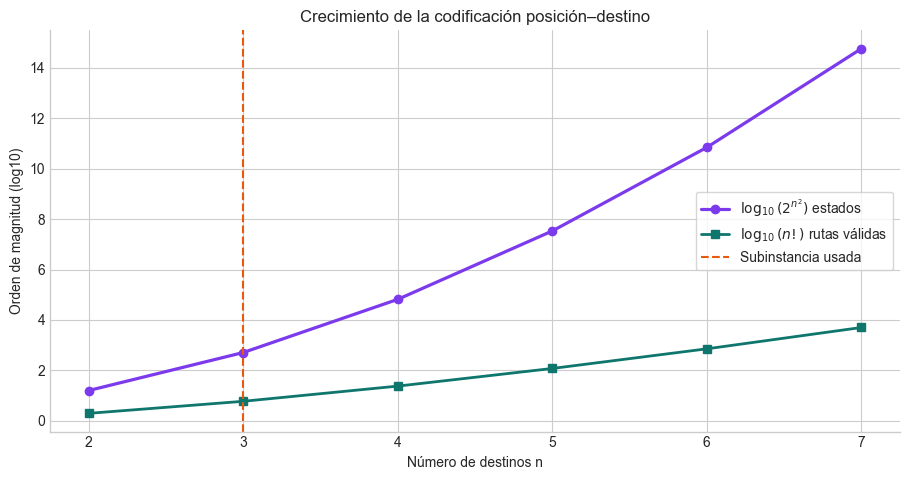

In [14]:
scaling_rows = []
for n_destinations in range(2, 8):
    qubits = n_destinations ** 2
    log10_hilbert = qubits * math.log10(2.0)
    valid_routes = math.factorial(n_destinations)
    feasible_fraction_log10 = (
        math.log10(valid_routes) - log10_hilbert
    )
    scaling_rows.append(
        {
            "DESTINATIONS": n_destinations,
            "POSITION_VARIABLES_QUBITS": qubits,
            "VALID_ROUTES": valid_routes,
            "LOG10_HILBERT_STATES": log10_hilbert,
            "LOG10_FEASIBLE_FRACTION": (
                feasible_fraction_log10
            ),
        }
    )
qaoa_scaling = pd.DataFrame(scaling_rows)
display(qaoa_scaling)

fig, ax = plt.subplots(figsize=(9.2, 4.9))
ax.plot(
    qaoa_scaling["DESTINATIONS"],
    qaoa_scaling["LOG10_HILBERT_STATES"],
    marker="o",
    linewidth=2.3,
    color="#7C3AED",
    label=r"$\log_{10}(2^{n^2})$ estados",
)
ax.plot(
    qaoa_scaling["DESTINATIONS"],
    np.log10(qaoa_scaling["VALID_ROUTES"]),
    marker="s",
    linewidth=2.0,
    color="#0F766E",
    label=r"$\log_{10}(n!)$ rutas válidas",
)
ax.axvline(
    N_DESTINATIONS,
    color="#EA580C",
    linestyle="--",
    label="Subinstancia usada",
)
ax.set_title("Crecimiento de la codificación posición–destino")
ax.set_xlabel("Número de destinos n")
ax.set_ylabel("Orden de magnitud (log10)")
ax.legend(frameon=True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
scaling_figure = FIGURES_DIR / "qaoa_scaling.png"
plt.savefig(scaling_figure, dpi=190, bbox_inches="tight")
plt.show()


## 10. Exportación y validaciones finales

Se guardan los coeficientes, ejecuciones, muestras, métricas y supuestos. Las aserciones verifican que:

- Tayacaja sea la fuente;
- el QUBO reproduzca exactamente la función de costo;
- el estado fundamental sea factible;
- la ruta seleccionada por QAOA exista en la enumeración clásica;
- todas las distancias del benchmark procedan de la matriz vial.


In [15]:
qubo_terms_path = RESULTS_DIR / "qaoa_qubo_terms.csv"
classical_routes_path = RESULTS_DIR / "qaoa_classical_routes.csv"
penalty_path = RESULTS_DIR / "qaoa_penalty_validation.csv"
depth_results_path = RESULTS_DIR / "qaoa_depth_results.csv"
restart_results_path = RESULTS_DIR / "qaoa_restart_results.csv"
sampled_path = RESULTS_DIR / "qaoa_sampled_solutions.csv"
benchmark_path = RESULTS_DIR / "phase5_benchmark.csv"
scaling_path = RESULTS_DIR / "qaoa_scaling.csv"
assumptions_path = RESULTS_DIR / "phase5_assumptions.csv"
resources_path = RESULTS_DIR / "qaoa_resources.csv"

resources = pd.DataFrame(
    {
        "RESOURCE": [
            "QUBITS",
            "HILBERT_STATES",
            "VALID_ROUTES",
            "LINEAR_TERMS",
            "QUADRATIC_TERMS",
            "BEST_DEPTH",
            "QISKIT_AVAILABLE",
            "QISKIT_CIRCUIT_DEPTH",
            "QISKIT_CIRCUIT_SIZE",
            "QISKIT_NUMPY_MAX_PROBABILITY_DIFF",
        ],
        "VALUE": [
            N_QUBITS,
            HILBERT_SIZE,
            math.factorial(N_DESTINATIONS),
            int(
                (qubo_terms["TERM_TYPE"] == "LINEAR").sum()
            ),
            int(
                (
                    qubo_terms["TERM_TYPE"]
                    == "QUADRATIC"
                ).sum()
            ),
            BEST_DEPTH,
            qiskit_available,
            qiskit_depth,
            qiskit_size,
            qiskit_probability_difference,
        ],
    }
)

assumptions = pd.DataFrame(
    {
        "PARAMETER": [
            "SOURCE_NODE_ID",
            "SOURCE_NAME",
            "OBJECTIVE",
            "SUBROUTE_ID",
            "SUBROUTE_DESTINATIONS",
            "QUBO_ENCODING",
            "PENALTY_MULTIPLIER",
            "PENALTY_A",
            "QAOA_DEPTHS",
            "QAOA_RESTARTS",
            "QAOA_MAXITER",
            "SHOTS",
            "SIMULATOR",
            "CLAIM",
        ],
        "VALUE": [
            SOURCE_ID,
            SOURCE_NAME,
            "ROAD_DISTANCE_KM_OSRM",
            SUBROUTE_ID,
            "|".join(sub_customers),
            "DESTINATION_POSITION",
            PENALTY_MULTIPLIER,
            PENALTY_A,
            "|".join(map(str, QAOA_DEPTHS)),
            QAOA_RESTARTS,
            QAOA_MAXITER,
            SHOTS,
            "EXACT_NUMPY_STATEVECTOR",
            "PROOF_OF_CONCEPT_NO_QUANTUM_ADVANTAGE",
        ],
    }
)

qubo_terms.to_csv(
    qubo_terms_path, index=False, encoding="utf-8-sig"
)
classical_routes.to_csv(
    classical_routes_path, index=False, encoding="utf-8-sig"
)
penalty_validation.to_csv(
    penalty_path, index=False, encoding="utf-8-sig"
)
qaoa_depth_results.to_csv(
    depth_results_path, index=False, encoding="utf-8-sig"
)
qaoa_restarts.to_csv(
    restart_results_path, index=False, encoding="utf-8-sig"
)
qaoa_sampled.to_csv(
    sampled_path, index=False, encoding="utf-8-sig"
)
benchmark.to_csv(
    benchmark_path, index=False, encoding="utf-8-sig"
)
qaoa_scaling.to_csv(
    scaling_path, index=False, encoding="utf-8-sig"
)
assumptions.to_csv(
    assumptions_path, index=False, encoding="utf-8-sig"
)
resources.to_csv(
    resources_path, index=False, encoding="utf-8-sig"
)

assert SOURCE_ID == "DC00"
assert "TAYACAJA" in SOURCE_NAME.upper()
assert len(sub_customers) == 3
assert N_QUBITS == 9
assert np.allclose(
    qubo_energies_direct,
    qubo_energies_polynomial,
)
assert np.array_equal(global_ground_mask, optimal_mask)
assert np.isclose(
    CLASSICAL_OPTIMUM_KM,
    float(target_route["DISTANCE_KM"]),
)
assert qaoa_selected_order in set(
    permutations(sub_customers)
)
assert np.isclose(
    qaoa_selected_cost_km,
    classical_routes.loc[
        classical_routes["ORDER_NODE_IDS"].eq(
            " -> ".join(qaoa_selected_order)
        ),
        "ROAD_DISTANCE_KM",
    ].iloc[0],
)
assert qaoa_depth_results[
    "FEASIBILITY_PROBABILITY"
].between(0.0, 1.0).all()
assert qaoa_depth_results[
    "OPTIMUM_PROBABILITY"
].between(0.0, 1.0).all()
if qiskit_available:
    assert qiskit_probability_difference < 1e-8

exported = pd.DataFrame(
    {
        "ARCHIVO": [
            qubo_terms_path,
            classical_routes_path,
            penalty_path,
            depth_results_path,
            restart_results_path,
            sampled_path,
            benchmark_path,
            scaling_path,
            assumptions_path,
            resources_path,
            penalty_figure,
            depth_figure,
            distribution_figure,
            comparison_figure,
            scaling_figure,
        ]
    }
)
print("Validaciones de la Fase 5 completadas correctamente.")
display(exported)


Validaciones de la Fase 5 completadas correctamente.


,ARCHIVO
0,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\qaoa_qubo_terms.csv
1,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\qaoa_classical_routes.csv
2,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\qaoa_penalty_validation.csv
3,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\qaoa_depth_results.csv
4,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\qaoa_restart_results.csv
5,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\qaoa_sampled_solutions.csv
6,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\phase5_benchmark.csv
7,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\qaoa_scaling.csv
8,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\phase5_assumptions.csv
9,O:\Mi unidad\Física - PUCP\2026-1\hackaton\QHub_Logistica_Transporte\data\results\qaoa_resources.csv


## Conclusiones de la Fase 5

- QAOA recibe directamente un QUBO construido con **kilómetros por carretera** desde y hacia el almacén de Tayacaja.
- La demostración usa una ruta real de tres destinos de la solución CVRP: no sustituye la asignación completa de siete destinos.
- La enumeración clásica de seis rutas proporciona el óptimo verificable; vecino más cercano funciona como baseline heurístico.
- QAOA no recibe el índice del óptimo. Ajusta sus parámetros minimizando la energía esperada y luego se decodifican sus mediciones.
- La probabilidad de factibilidad, la probabilidad del óptimo y el *gap* se reportan por separado.
- El crecimiento de $n^2$ qubits y $2^{n^2}$ amplitudes limita la simulación exacta. Por ello no se afirma ventaja cuántica ni se extrapola el resultado al CVRP completo.

La siguiente fase debe consolidar resultados, limitaciones, narrativa de impacto y material de presentación.
